In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


In [30]:
df = pd.read_csv('F:\Prediction\industrial_sensor_anomaly_dataset_100k.csv')

In [31]:
df.shape

(100000, 7)

In [32]:
df.isnull().sum()

timestamp                0
sensor_temperature       0
sensor_pressure          0
sensor_vibration         0
sensor_voltage           0
sensor_rotation_speed    0
anomaly_label            0
dtype: int64

In [33]:
df.columns

Index(['timestamp', 'sensor_temperature', 'sensor_pressure',
       'sensor_vibration', 'sensor_voltage', 'sensor_rotation_speed',
       'anomaly_label'],
      dtype='object')

In [34]:
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)

In [35]:
df['timestamp'].min(),df['timestamp'].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2024-03-10 10:39:00'))

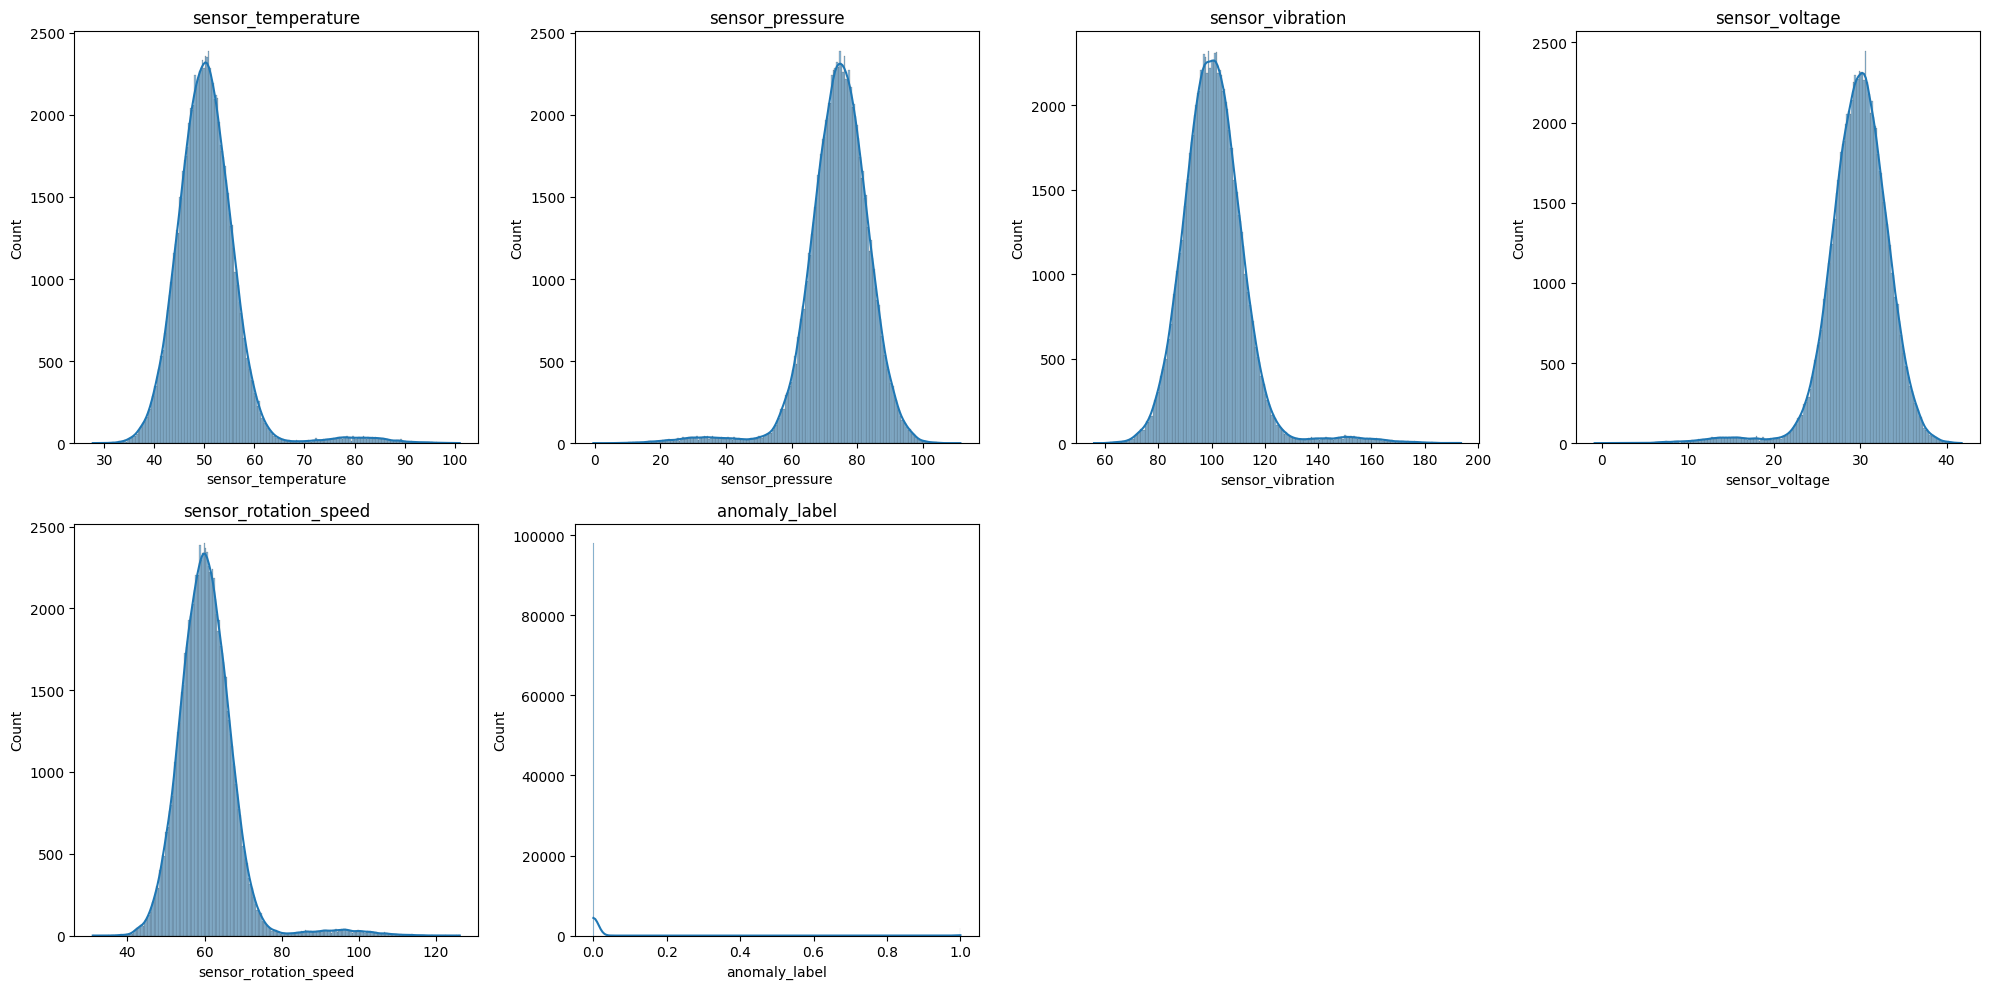

In [36]:
cols = df.select_dtypes(include='number').columns

n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(20, 5*n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

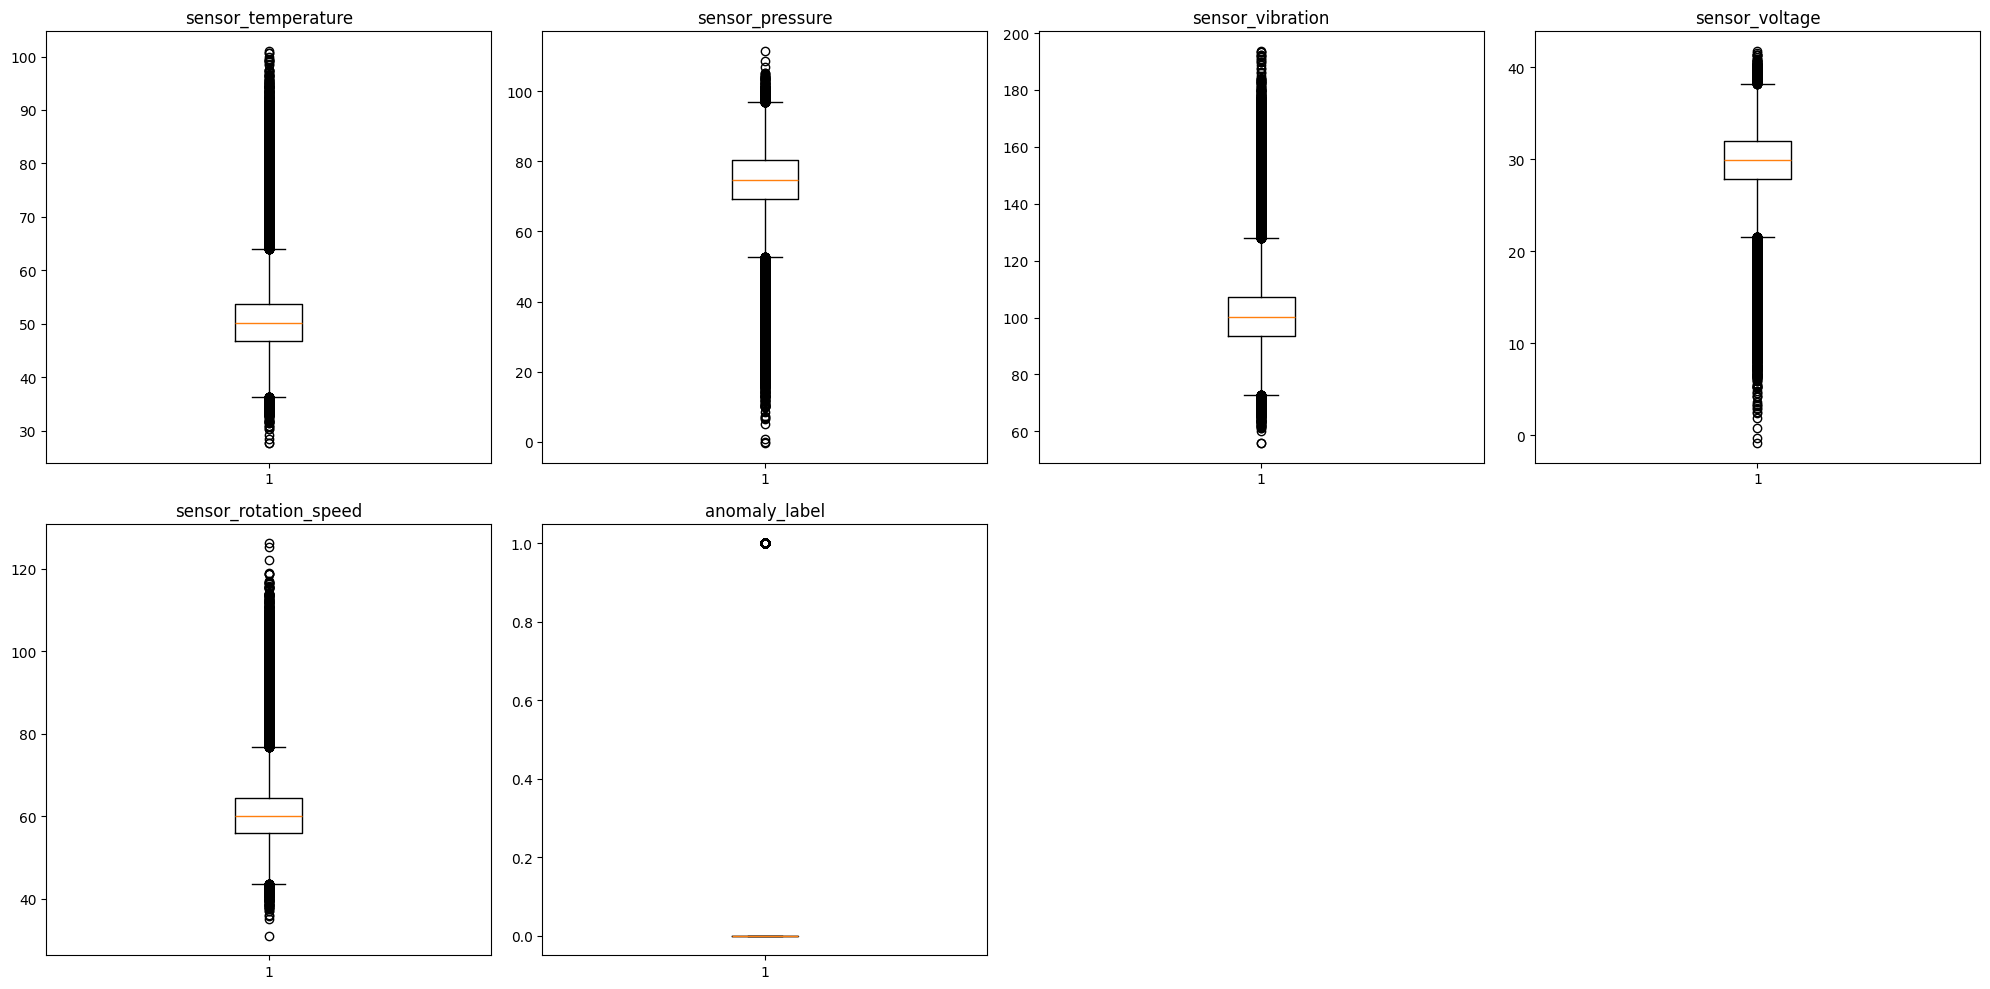

In [37]:
cols = df.select_dtypes(include=['int64','float64']).columns

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5*n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

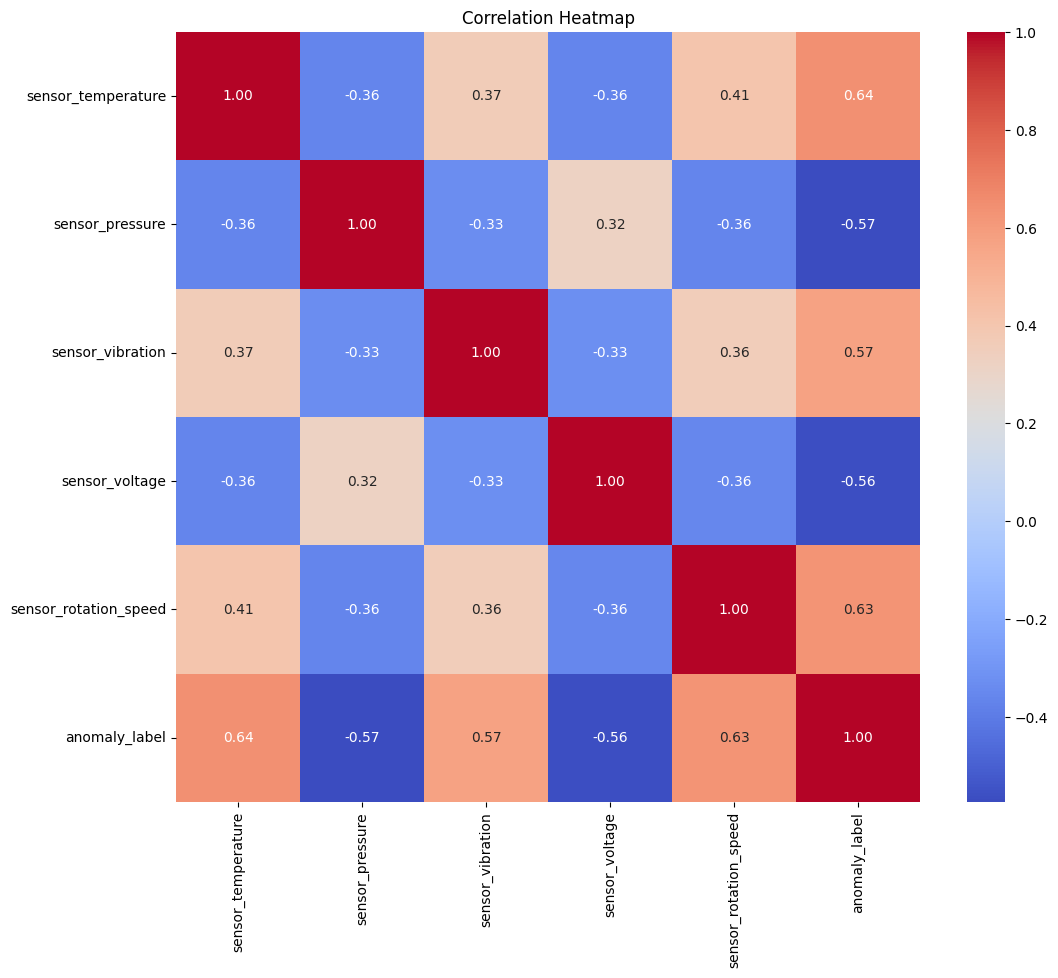

In [38]:
corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [39]:
df = df.drop("timestamp", axis=1)

X = df.drop("anomaly_label", axis=1)
y = df["anomaly_label"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [41]:
iso_model = IsolationForest(contamination=0.02, random_state=42)

iso_model.fit(X_scaled)

iso_pred = iso_model.predict(X_scaled)

iso_pred = np.where(iso_pred == -1, 1, 0)

In [42]:
print("Isolation Forest Performance")

print("Precision:", precision_score(y, iso_pred))
print("Recall:", recall_score(y, iso_pred))
print("F1 Score:", f1_score(y, iso_pred))

Isolation Forest Performance
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [45]:
df["predicted_anomaly"] = iso_pred

alerts = df[df["predicted_anomaly"] == 1]

print("Detected Failures:", alerts.shape[0])

Detected Failures: 2000


In [46]:
for i in range(10):
    
    if iso_pred[i] == 1:
        print("⚠ Equipment Failure Detected at index:", i)
        
    else:
        print("Normal Operation")

Normal Operation
Normal Operation
⚠ Equipment Failure Detected at index: 2
Normal Operation
Normal Operation
Normal Operation
Normal Operation
Normal Operation
Normal Operation
Normal Operation


In [47]:
healthy_df = df[df["anomaly_label"] == 0]

X_train = healthy_df.drop(["anomaly_label"], axis=1)

X_test = df.drop(["anomaly_label"], axis=1)

y_test = df["anomaly_label"]

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [49]:
from sklearn.decomposition import PCA

pca = PCA(0.95)

pca.fit(X_train_scaled)

,n_components,0.95
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [50]:
X_test_pca = pca.transform(X_test_scaled)

X_reconstructed = pca.inverse_transform(X_test_pca)

error = ((X_test_scaled - X_reconstructed) ** 2).mean(axis=1)

In [51]:
train_pca = pca.transform(X_train_scaled)

train_recon = pca.inverse_transform(train_pca)

train_error = ((X_train_scaled - train_recon) ** 2).mean(axis=1)

threshold = np.percentile(train_error, 99)

In [52]:
pca_pred = (error > threshold).astype(int)

In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, pca_pred))
print("Recall:", recall_score(y_test, pca_pred))
print("F1 Score:", f1_score(y_test, pca_pred))

Precision: 0.671366230278617
Recall: 1.0
F1 Score: 0.8033741715203856


In [55]:
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pca_pred)

TN, FP, FN, TP = cm.ravel()

total_failures = TP + FN
failures_identified = TP
failures_missed = FN
false_alarms = FP

print("Total failures present:", total_failures)
print("Failures identified:", failures_identified)
print("Failures missed:", failures_missed)
print("False alarms generated:", false_alarms)

Total failures present: 2000
Failures identified: 2000
Failures missed: 0
False alarms generated: 979


In [56]:
total_alerts = TP + FP

print("Total alerts generated:", total_alerts)

Total alerts generated: 2979


In [57]:
print("\n----- Anomaly Detection Summary -----")

print("Total Data Points:", len(y_test))
print("Total Failures Present:", TP + FN)
print("Failures Detected:", TP)
print("Failures Missed:", FN)
print("False Alarms:", FP)
print("Correct Normal Predictions:", TN)
print("Total Alerts Generated:", TP + FP)


----- Anomaly Detection Summary -----
Total Data Points: 100000
Total Failures Present: 2000
Failures Detected: 2000
Failures Missed: 0
False Alarms: 979
Correct Normal Predictions: 97021
Total Alerts Generated: 2979
